## Section 1: Setup and Data Loading
Here we import all necessary libraries, load the dataset from HuggingFace,
filter it to our 15 selected classes, and define a custom PyTorch Dataset
class that will be reused across all three models.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

print("⏳ Loading dataset...")
dataset = load_dataset("rajistics/indian_food_images")
print("✅ Dataset loaded!")

SELECTED_CLASSES = [
    'idli', 'masala_dosa', 'dhokla', 'paani_puri', 'pakode',
    'chai', 'samosa', 'pav_bhaji', 'fried_rice', 'jalebi',
    'butter_naan', 'kadai_paneer', 'kulfi', 'chapati', 'chole_bhature'
]

all_classes = dataset["train"].features["label"].names
selected_idx = [all_classes.index(c) for c in SELECTED_CLASSES]
old_to_new = {old: new for new, old in enumerate(selected_idx)}

def filter_split(split):
    return [(ex["image"], old_to_new[ex["label"]])
            for ex in dataset[split]
            if ex["label"] in old_to_new]

train_samples = filter_split("train")
test_samples  = filter_split("test")

class FoodDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        image, label = self.samples[idx]
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

print(f"✅ Train samples: {len(train_samples)}")
print(f"✅ Test  samples: {len(test_samples)}")
print(f"✅ Classes: {SELECTED_CLASSES}")
print("✅ All setup done!")

✅ Device: cuda
⏳ Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/660 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-dbae6752a5d31c(…):   0%|          | 0.00/1.36G [00:00<?, ?B/s]

data/test-00000-of-00001-899c7c7e401d279(…):   0%|          | 0.00/241M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5328 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/941 [00:00<?, ? examples/s]

✅ Dataset loaded!
✅ Train samples: 4062
✅ Test  samples: 704
✅ Classes: ['idli', 'masala_dosa', 'dhokla', 'paani_puri', 'pakode', 'chai', 'samosa', 'pav_bhaji', 'fried_rice', 'jalebi', 'butter_naan', 'kadai_paneer', 'kulfi', 'chapati', 'chole_bhature']
✅ All setup done!


Section 2: Data Exploration

2.1 Sample Images from Each Class
Visualizing one sample image from each of the 15 selected classes
to understand what the data looks like.

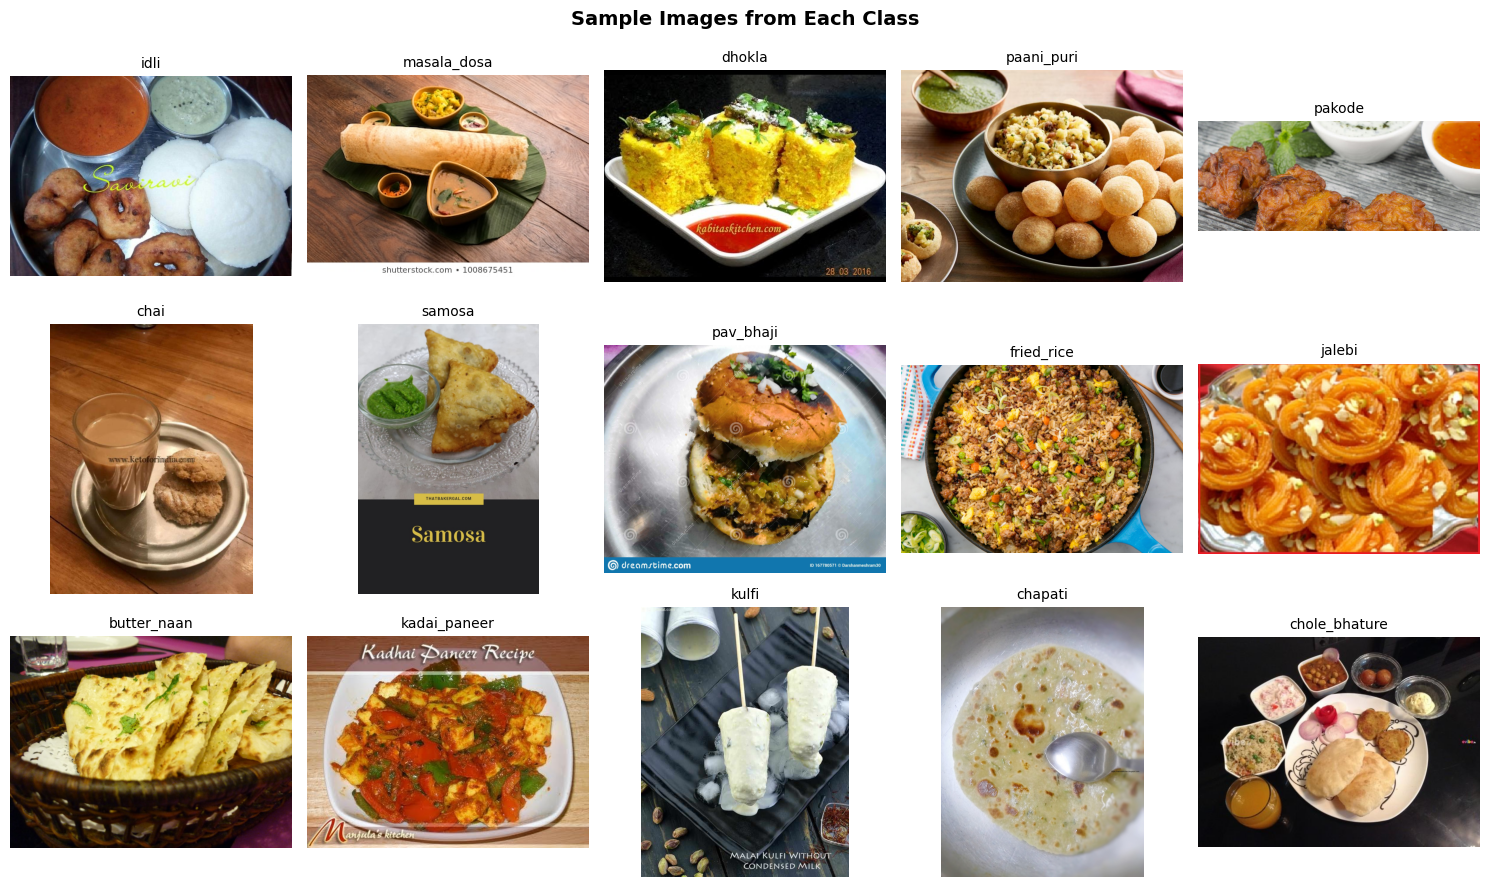

In [ ]:
# 2.1 - Sample images
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, class_name in enumerate(SELECTED_CLASSES):
    for img, label in train_samples:
        if label == i:
            axes[i].imshow(img)
            axes[i].set_title(class_name, fontsize=10)
            axes[i].axis('off')
            break

plt.suptitle("Sample Images from Each Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

2.2 Class Balance
Checking if the dataset is balanced — i.e. does each class have
roughly the same number of images? Imbalanced classes can cause
the model to be biased toward majority classes.

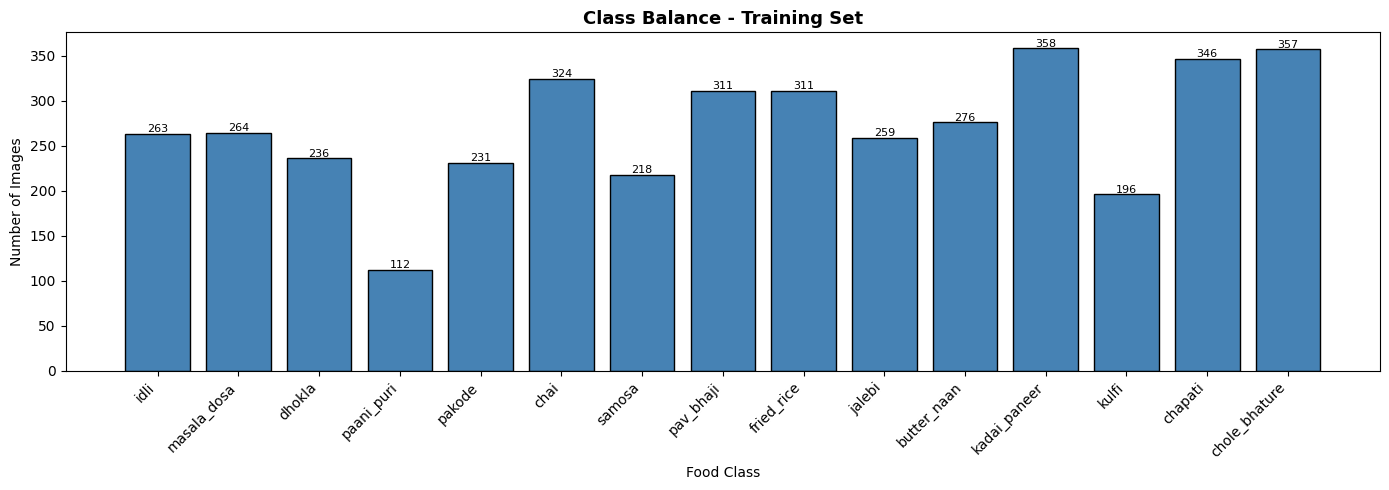

In [ ]:
# 2.2 - Class balance
train_labels = [label for _, label in train_samples]
class_counts = [train_labels.count(i) for i in range(len(SELECTED_CLASSES))]

plt.figure(figsize=(14, 5))
bars = plt.bar(SELECTED_CLASSES, class_counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title("Class Balance - Training Set", fontsize=13, fontweight='bold')
plt.ylabel("Number of Images")
plt.xlabel("Food Class")
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(count), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

Key Observations

The dataset is slightly imbalanced. `paani_puri` has
the fewest images (112) while `kadai_paneer` has the most (358).
This is a 3x difference which could cause the model to perform
slightly worse on underrepresented classes. We will use data
augmentation to help compensate for this imbalance.

2.3 Dataset Summary Statistics
A quick numerical summary of the dataset — total images,
images per class, and train/test split.

In [ ]:
# 2.3 - Summary statistics
print(f"Total training images : {len(train_samples)}")
print(f"Total test images     : {len(test_samples)}")
print(f"Number of classes     : {len(SELECTED_CLASSES)}")
print(f"Avg images per class  : {len(train_samples) // len(SELECTED_CLASSES)}")
print(f"\nPer class image count:")
print("-" * 35)
for i, cls in enumerate(SELECTED_CLASSES):
    bar = "█" * (class_counts[i] // 10)
    print(f"  {cls:<20} {class_counts[i]:>3} images  {bar}")

Total training images : 4062
Total test images     : 704
Number of classes     : 15
Avg images per class  : 270

Per class image count:
-----------------------------------
  idli                 263 images  ██████████████████████████
  masala_dosa          264 images  ██████████████████████████
  dhokla               236 images  ███████████████████████
  paani_puri           112 images  ███████████
  pakode               231 images  ███████████████████████
  chai                 324 images  ████████████████████████████████
  samosa               218 images  █████████████████████
  pav_bhaji            311 images  ███████████████████████████████
  fried_rice           311 images  ███████████████████████████████
  jalebi               259 images  █████████████████████████
  butter_naan          276 images  ███████████████████████████
  kadai_paneer         358 images  ███████████████████████████████████
  kulfi                196 images  ███████████████████
  chapati              346 ima

## Section 3: Preprocessing & MLP

3.1 Preprocessing & Augmentation
We resize all images to 128x128 for the MLP (smaller = fewer parameters =
faster training). We apply data augmentation only on the training set to
prevent overfitting.


In [ ]:
# 3.1 - Transforms for MLP
IMG_SIZE = 128

# Training transform - with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/test transform - NO augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Split train into train/val (80/20)
val_size = int(0.2 * len(train_samples))
train_size = len(train_samples) - val_size
train_subset, val_subset = random_split(train_samples, [train_size, val_size])

# Create datasets
train_dataset = FoodDataset(list(train_subset), transform=train_transform)
val_dataset   = FoodDataset(list(val_subset),   transform=val_transform)
test_dataset  = FoodDataset(test_samples,        transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"✅ Train batches : {len(train_loader)}")
print(f"✅ Val batches   : {len(val_loader)}")
print(f"✅ Test batches  : {len(test_loader)}")
print(f"✅ Image size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"✅ Batch size    : 32")

✅ Train batches : 102
✅ Val batches   : 26
✅ Test batches  : 22
✅ Image size    : 128x128
✅ Batch size    : 32


3.2 Building the MLP Model
A Multi-Layer Perceptron (MLP) flattens the image into a 1D vector
and passes it through fully connected layers. It has no understanding
of spatial structure — every pixel is treated independently. This is
why MLPs usually struggle with image classification.

Input size: 128 x 128 x 3 = 49,152 pixels → flattened into one long vector

In [ ]:
# 3.2 - MLP Model
class MLP(nn.Module):
    def __init__(self, num_classes=15):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 128 * 3, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

mlp_model = MLP(num_classes=15).to(device)

# Count parameters
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"✅ MLP Model created")
print(f"✅ Total parameters: {total_params:,}")

✅ MLP Model created
✅ Total parameters: 50,992,655


3.3 Training the MLP
We train the MLP for 10 epochs using CrossEntropyLoss and Adam optimizer.
We track train and validation accuracy after each epoch to plot learning curves.


In [ ]:
# 3.3 - Training function (reused for all 3 models)
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_accs, val_accs = [], []
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_acc  = correct / total
        train_loss = running_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        correct, total, running_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_acc  = correct / total
        val_loss = running_loss / len(val_loader)

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return train_accs, val_accs, train_losses, val_losses

# Train MLP
print("🚀 Training MLP...")
mlp_train_accs, mlp_val_accs, mlp_train_losses, mlp_val_losses = train_model(
    mlp_model, train_loader, val_loader, epochs=10, lr=0.001
)
print("✅ MLP Training complete!")

🚀 Training MLP...
Epoch 01/10 | Train Loss: 3.7205 | Train Acc: 0.0969 | Val Loss: 2.6141 | Val Acc: 0.1121
Epoch 02/10 | Train Loss: 2.6955 | Train Acc: 0.1203 | Val Loss: 2.6086 | Val Acc: 0.1355
Epoch 03/10 | Train Loss: 2.6221 | Train Acc: 0.1255 | Val Loss: 2.5302 | Val Acc: 0.1318
Epoch 04/10 | Train Loss: 2.5780 | Train Acc: 0.1385 | Val Loss: 2.5057 | Val Acc: 0.1724
Epoch 05/10 | Train Loss: 2.5528 | Train Acc: 0.1508 | Val Loss: 2.5119 | Val Acc: 0.1576
Epoch 06/10 | Train Loss: 2.5519 | Train Acc: 0.1403 | Val Loss: 2.4640 | Val Acc: 0.1773
Epoch 07/10 | Train Loss: 2.5131 | Train Acc: 0.1566 | Val Loss: 2.5049 | Val Acc: 0.1466
Epoch 08/10 | Train Loss: 2.5160 | Train Acc: 0.1563 | Val Loss: 2.4859 | Val Acc: 0.1650
Epoch 09/10 | Train Loss: 2.5236 | Train Acc: 0.1474 | Val Loss: 2.5109 | Val Acc: 0.1453
Epoch 10/10 | Train Loss: 2.4932 | Train Acc: 0.1594 | Val Loss: 2.4886 | Val Acc: 0.1700
✅ MLP Training complete!


3.4 MLP Learning Curves & Evaluation

After training, we plot the learning curves to visualize how the model
improved (or didn't) over epochs. We then evaluate on the test set and
generate a confusion matrix to see which classes the model confuses
with each other.

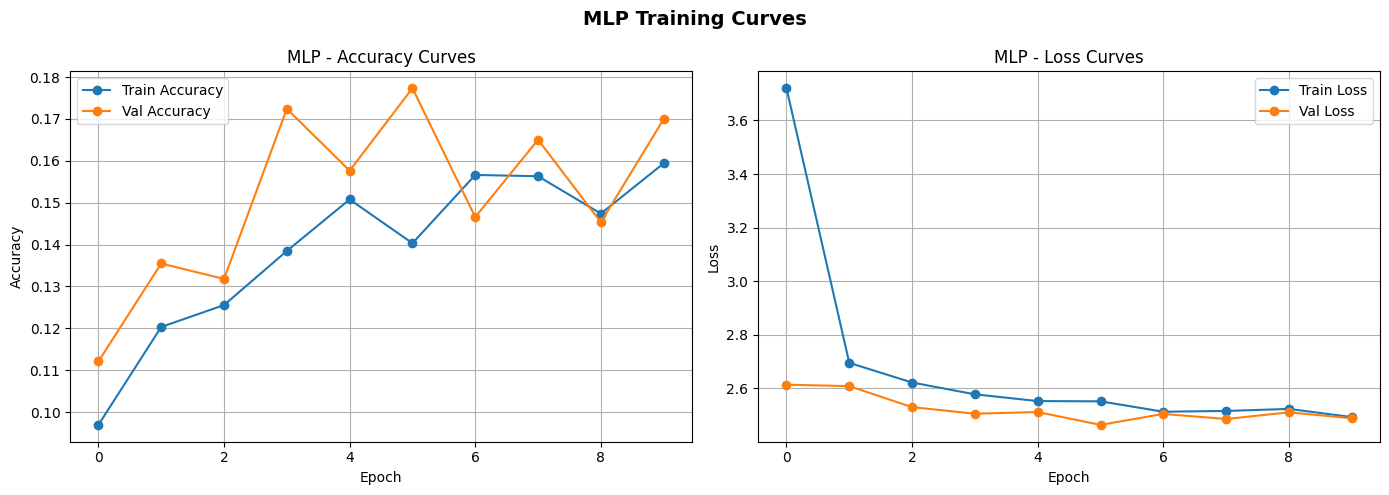

✅ MLP Test Accuracy: 0.1719 (17.19%)


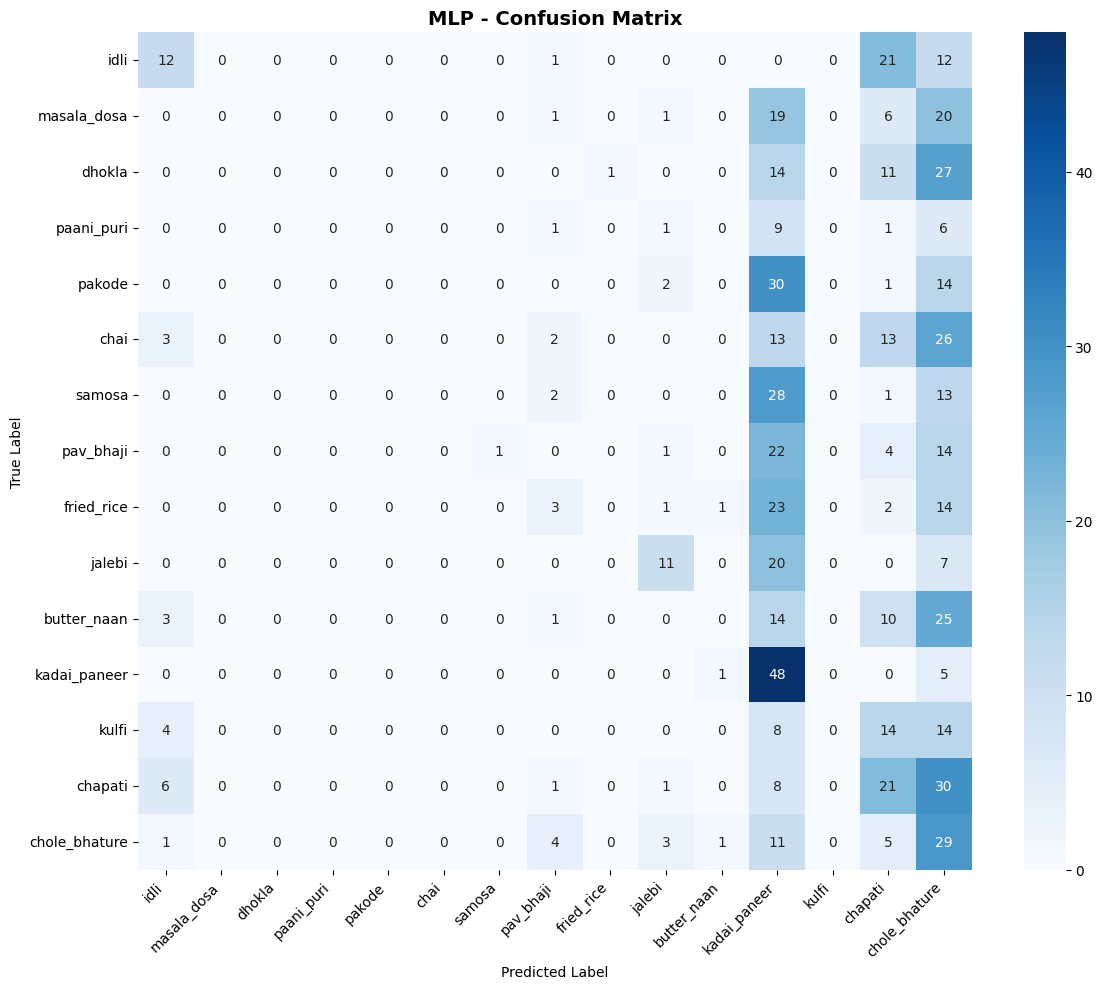


Per-class accuracy:
-----------------------------------
  idli                 26.1%
  masala_dosa          0.0%
  dhokla               0.0%
  paani_puri           0.0%
  pakode               0.0%
  chai                 0.0%
  samosa               0.0%
  pav_bhaji            0.0%
  fried_rice           0.0%
  jalebi               28.9%
  butter_naan          0.0%
  kadai_paneer         88.9%
  kulfi                0.0%
  chapati              31.3%
  chole_bhature        53.7%


In [ ]:
# 3.4 - Plot MLP learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mlp_train_accs, label='Train Accuracy', marker='o')
ax1.plot(mlp_val_accs,   label='Val Accuracy',   marker='o')
ax1.set_title('MLP - Accuracy Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(mlp_train_losses, label='Train Loss', marker='o')
ax2.plot(mlp_val_losses,   label='Val Loss',   marker='o')
ax2.set_title('MLP - Loss Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('MLP Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.5 - Evaluate MLP on test set
mlp_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = mlp_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

mlp_test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"✅ MLP Test Accuracy: {mlp_test_acc:.4f} ({mlp_test_acc*100:.2f}%)")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SELECTED_CLASSES,
            yticklabels=SELECTED_CLASSES)
plt.title('MLP - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Per class accuracy
print("\nPer-class accuracy:")
print("-" * 35)
for i, cls in enumerate(SELECTED_CLASSES):
    cls_mask = [l == i for l in all_labels]
    cls_preds = [p for p, m in zip(all_preds, cls_mask) if m]
    cls_labels = [l for l, m in zip(all_labels, cls_mask) if m]
    cls_acc = sum(p == l for p, l in zip(cls_preds, cls_labels)) / len(cls_labels)
    print(f"  {cls:<20} {cls_acc*100:.1f}%")

In [ ]:
print(f"Device: {device}")
print(f"Train samples: {len(train_samples)}")
print(f"Test samples: {len(test_samples)}")
print(f"Classes: {SELECTED_CLASSES}")
print(f"MLP model: {mlp_model}")

Device: cuda
Train samples: 4062
Test samples: 704
Classes: ['idli', 'masala_dosa', 'dhokla', 'paani_puri', 'pakode', 'chai', 'samosa', 'pav_bhaji', 'fried_rice', 'jalebi', 'butter_naan', 'kadai_paneer', 'kulfi', 'chapati', 'chole_bhature']
MLP model: MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=49152, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=512, out_features=256, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=256, out_features=15, bias=True)
  )
)


## Section 4: CNN from Scratch

### 4.1 Building the CNN Model
Unlike the MLP, a CNN uses convolutional layers to detect spatial
features like edges, shapes and textures. It scans the image with
small filters rather than flattening everything into one vector.

Architecture used:
- Conv → BatchNorm → ReLU → MaxPool (repeated 3 times)
- Channels grow: 3 → 32 → 64 → 128
- Stride-2 layers reduce spatial dimensions
- Final fully connected layer for classification

This should perform significantly better than the MLP with
far fewer parameters.

In [ ]:
# 4.1 - CNN Model
class CNN(nn.Module):
    def __init__(self, num_classes=15):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 128x128 -> 64x64

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64x64 -> 32x32

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32x32 -> 16x16

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16 -> 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = CNN(num_classes=15).to(device)

# Count parameters
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"✅ CNN Model created")
print(f"✅ Total parameters: {total_params:,}")

✅ CNN Model created
✅ Total parameters: 8,786,191


### 4.2 Training the CNN
We train the CNN for 15 epochs — more than the MLP because the CNN
has more to learn (filters, spatial features). We use the same
training function from before.

Expected result: CNN should significantly outperform the MLP
despite having 6x fewer parameters.

In [ ]:
# 4.2 - Train CNN
print("🚀 Training CNN...")
cnn_train_accs, cnn_val_accs, cnn_train_losses, cnn_val_losses = train_model(
    cnn_model, train_loader, val_loader, epochs=15, lr=0.001
)
print("✅ CNN Training complete!")

🚀 Training CNN...
Epoch 01/15 | Train Loss: 3.6467 | Train Acc: 0.1225 | Val Loss: 2.4848 | Val Acc: 0.1663
Epoch 02/15 | Train Loss: 2.5356 | Train Acc: 0.1406 | Val Loss: 2.4242 | Val Acc: 0.1946
Epoch 03/15 | Train Loss: 2.4904 | Train Acc: 0.1471 | Val Loss: 2.3833 | Val Acc: 0.1638
Epoch 04/15 | Train Loss: 2.4487 | Train Acc: 0.1615 | Val Loss: 2.3421 | Val Acc: 0.2352
Epoch 05/15 | Train Loss: 2.4096 | Train Acc: 0.1689 | Val Loss: 2.1805 | Val Acc: 0.2500
Epoch 06/15 | Train Loss: 2.3770 | Train Acc: 0.1865 | Val Loss: 2.2155 | Val Acc: 0.2549
Epoch 07/15 | Train Loss: 2.3671 | Train Acc: 0.1735 | Val Loss: 2.1776 | Val Acc: 0.2586
Epoch 08/15 | Train Loss: 2.3212 | Train Acc: 0.1972 | Val Loss: 2.1198 | Val Acc: 0.2968
Epoch 09/15 | Train Loss: 2.3207 | Train Acc: 0.2138 | Val Loss: 2.1475 | Val Acc: 0.2808
Epoch 10/15 | Train Loss: 2.2885 | Train Acc: 0.2138 | Val Loss: 2.0543 | Val Acc: 0.2882
Epoch 11/15 | Train Loss: 2.2761 | Train Acc: 0.2212 | Val Loss: 2.0718 | Val Acc:

 CNN is not performing as well as expected. Best val accuracy is only 23.4% which is just slightly better than the MLP's 16.75%

Retrain with better settings:

In [ ]:
# Reset CNN model fresh
cnn_model = CNN(num_classes=15).to(device)

# Use lower learning rate + more epochs
print("🚀 Retraining CNN with better settings...")
cnn_train_accs, cnn_val_accs, cnn_train_losses, cnn_val_losses = train_model(
    cnn_model, train_loader, val_loader, epochs=20, lr=0.0003
)
print("✅ CNN Training complete!")

🚀 Retraining CNN with better settings...
Epoch 01/20 | Train Loss: 2.7637 | Train Acc: 0.1289 | Val Loss: 2.4175 | Val Acc: 0.2032
Epoch 02/20 | Train Loss: 2.3866 | Train Acc: 0.2095 | Val Loss: 2.1710 | Val Acc: 0.2869
Epoch 03/20 | Train Loss: 2.2351 | Train Acc: 0.2548 | Val Loss: 2.2439 | Val Acc: 0.2549
Epoch 04/20 | Train Loss: 2.1601 | Train Acc: 0.2754 | Val Loss: 1.9312 | Val Acc: 0.3855
Epoch 05/20 | Train Loss: 2.0955 | Train Acc: 0.3197 | Val Loss: 1.8420 | Val Acc: 0.3892
Epoch 06/20 | Train Loss: 2.0357 | Train Acc: 0.3289 | Val Loss: 1.8171 | Val Acc: 0.4187
Epoch 07/20 | Train Loss: 1.9888 | Train Acc: 0.3388 | Val Loss: 1.8823 | Val Acc: 0.4113
Epoch 08/20 | Train Loss: 1.9438 | Train Acc: 0.3671 | Val Loss: 1.7616 | Val Acc: 0.4397
Epoch 09/20 | Train Loss: 1.9204 | Train Acc: 0.3634 | Val Loss: 1.7776 | Val Acc: 0.4483
Epoch 10/20 | Train Loss: 1.8966 | Train Acc: 0.3634 | Val Loss: 1.7713 | Val Acc: 0.4360
Epoch 11/20 | Train Loss: 1.8552 | Train Acc: 0.3892 | Val 

 best val accuracy is 52.09% (Epoch 17), very similar to before

 Plot CNN learning curves +
 and  Evaluate

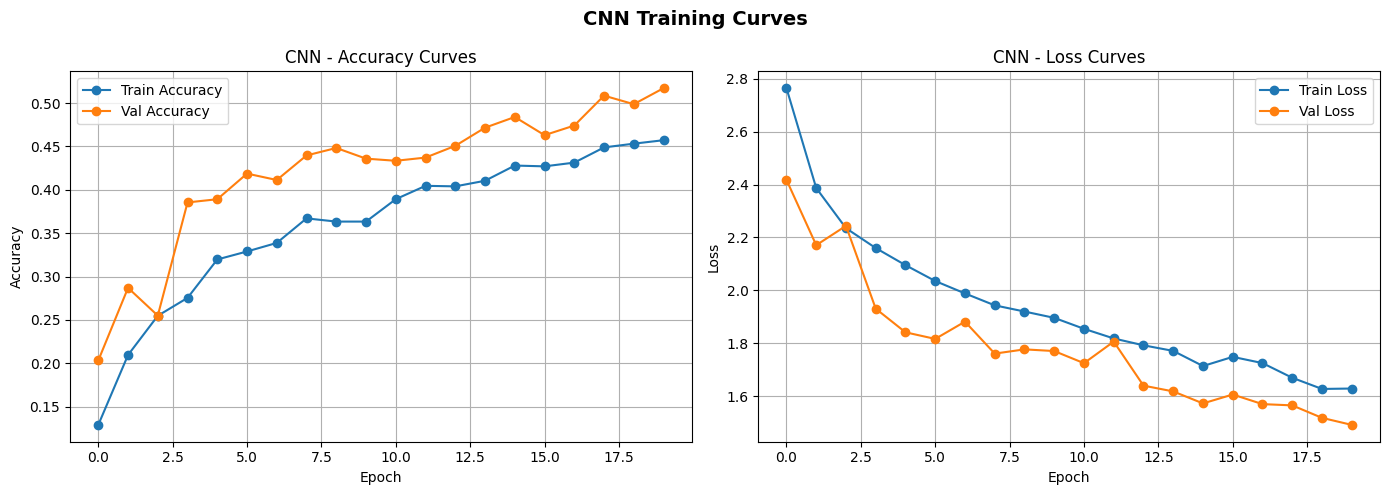

✅ CNN Test Accuracy: 0.5455 (54.55%)


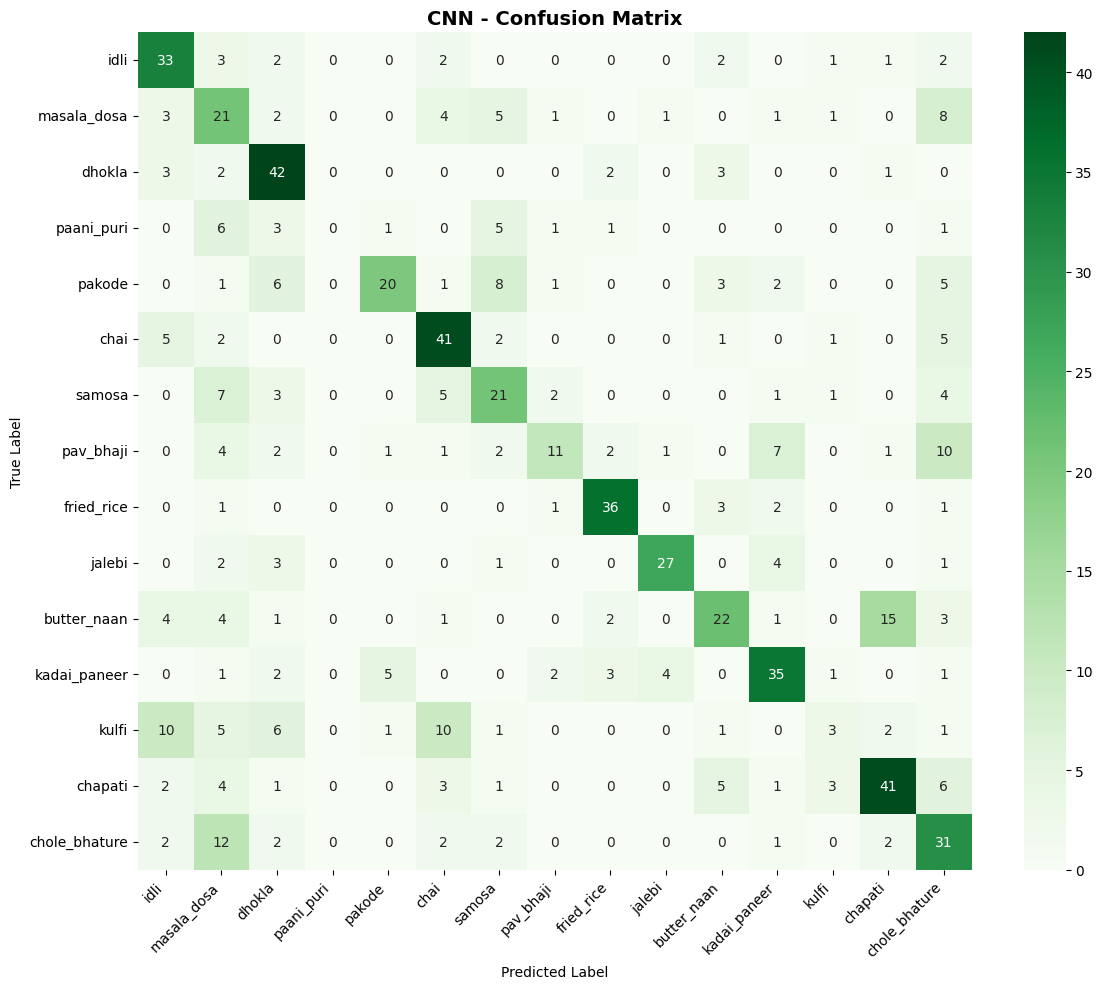


Per-class accuracy:
-----------------------------------
  idli                 71.7%
  masala_dosa          44.7%
  dhokla               79.2%
  paani_puri           0.0%
  pakode               42.6%
  chai                 71.9%
  samosa               47.7%
  pav_bhaji            26.2%
  fried_rice           81.8%
  jalebi               71.1%
  butter_naan          41.5%
  kadai_paneer         64.8%
  kulfi                7.5%
  chapati              61.2%
  chole_bhature        57.4%


In [ ]:
# 4.3 - Plot CNN learning curves + Evaluate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_train_accs, label='Train Accuracy', marker='o')
ax1.plot(cnn_val_accs,   label='Val Accuracy',   marker='o')
ax1.set_title('CNN - Accuracy Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(cnn_train_losses, label='Train Loss', marker='o')
ax2.plot(cnn_val_losses,   label='Val Loss',   marker='o')
ax2.set_title('CNN - Loss Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Evaluate on test set
cnn_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cnn_test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"✅ CNN Test Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=SELECTED_CLASSES,
            yticklabels=SELECTED_CLASSES)
plt.title('CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPer-class accuracy:")
print("-" * 35)
for i, cls in enumerate(SELECTED_CLASSES):
    cls_mask = [l == i for l in all_labels]
    cls_preds = [p for p, m in zip(all_preds, cls_mask) if m]
    cls_labels = [l for l, m in zip(all_labels, cls_mask) if m]
    cls_acc = sum(p == l for p, l in zip(cls_preds, cls_labels)) / len(cls_labels)
    print(f"  {cls:<20} {cls_acc*100:.1f}%")

Section 5: Fine-tuning a Pretrained Model

### 5.1 Loading Pretrained Model
We use EfficientNet-B0 pretrained on ImageNet. Instead of training
from scratch, we start with weights already trained on 1.2 million
images and adapt them to our Indian food dataset.

Two phase approach:
- Phase 1: Freeze backbone, train only the classification head (3-5 epochs)
- Phase 2: Unfreeze everything, fine-tune with very low learning rate (10 epochs)

In [ ]:
# 5.1 - Load pretrained EfficientNet-B0
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load pretrained weights
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
ft_model = efficientnet_b0(weights=weights)

# Replace classification head for 15 classes
ft_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(ft_model.classifier[1].in_features, 15)
)

ft_model = ft_model.to(device)

# Freeze backbone
for param in ft_model.features.parameters():
    param.requires_grad = False

# Count parameters
total_params = sum(p.numel() for p in ft_model.parameters())
trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)

print(f"✅ EfficientNet-B0 loaded")
print(f"✅ Total parameters    : {total_params:,}")
print(f"✅ Trainable parameters: {trainable_params:,} (head only)")

# Use pretrained transforms (224x224 for ImageNet models)
ft_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

ft_transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# New dataloaders with 224x224 images
ft_train_dataset = FoodDataset(list(train_subset), transform=ft_transform_train)
ft_val_dataset   = FoodDataset(list(val_subset),   transform=ft_transform_val)
ft_test_dataset  = FoodDataset(test_samples,        transform=ft_transform_val)

ft_train_loader = DataLoader(ft_train_dataset, batch_size=32, shuffle=True,  num_workers=2)
ft_val_loader   = DataLoader(ft_val_dataset,   batch_size=32, shuffle=False, num_workers=2)
ft_test_loader  = DataLoader(ft_test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"✅ DataLoaders ready with 224x224 images")

✅ EfficientNet-B0 loaded
✅ Total parameters    : 4,026,763
✅ Trainable parameters: 19,215 (head only)
✅ DataLoaders ready with 224x224 images


### 5.2 Phase 1 - Train Classification Head Only
We freeze the backbone and only train the new classification head.
This prevents destroying the pretrained weights before the head
has learned something useful. Only 19,215 parameters are updated.

In [ ]:
# 5.2 - Phase 1: Train head only (backbone frozen)
print("🚀 Phase 1: Training head only (backbone frozen)...")
ft_train_accs1, ft_val_accs1, ft_train_losses1, ft_val_losses1 = train_model(
    ft_model, ft_train_loader, ft_val_loader, epochs=5, lr=0.001
)
print("✅ Phase 1 complete!")

🚀 Phase 1: Training head only (backbone frozen)...
Epoch 01/5 | Train Loss: 1.9385 | Train Acc: 0.5052 | Val Loss: 1.3539 | Val Acc: 0.7007
Epoch 02/5 | Train Loss: 1.1961 | Train Acc: 0.7151 | Val Loss: 1.0246 | Val Acc: 0.7254
Epoch 03/5 | Train Loss: 0.9902 | Train Acc: 0.7425 | Val Loss: 0.9261 | Val Acc: 0.7599
Epoch 04/5 | Train Loss: 0.8873 | Train Acc: 0.7637 | Val Loss: 0.8449 | Val Acc: 0.7599
Epoch 05/5 | Train Loss: 0.8247 | Train Acc: 0.7742 | Val Loss: 0.8011 | Val Acc: 0.7783
✅ Phase 1 complete!


5.3 Phase 2 - Unfreeze and Fine-tune Everything

In Phase 1 we only trained the classification head (19,215 parameters)
and already achieved 78.57% validation accuracy.

Now in Phase 2 we unfreeze the entire backbone and fine-tune all
4 million parameters together. We use a very low learning rate
(0.00003) — much lower than Phase 1 — to make small, careful
adjustments to the pretrained weights without destroying what
ImageNet training already learned.



In [ ]:
# 5.3 - Phase 2: Unfreeze everything and fine-tune
print("Unfreezing backbone...")
for param in ft_model.features.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f"✅ Trainable parameters now: {trainable_params:,}")

print("🚀 Phase 2: Fine-tuning entire model (20 epochs)...")
ft_train_accs2, ft_val_accs2, ft_train_losses2, ft_val_losses2 = train_model(
    ft_model, ft_train_loader, ft_val_loader, epochs=20, lr=0.00003
)
print("✅ Phase 2 complete!")

Unfreezing backbone...
✅ Trainable parameters now: 4,026,763
🚀 Phase 2: Fine-tuning entire model (20 epochs)...
Epoch 01/20 | Train Loss: 0.6327 | Train Acc: 0.8283 | Val Loss: 0.5963 | Val Acc: 0.8350
Epoch 02/20 | Train Loss: 0.4908 | Train Acc: 0.8643 | Val Loss: 0.5183 | Val Acc: 0.8559
Epoch 03/20 | Train Loss: 0.4123 | Train Acc: 0.8831 | Val Loss: 0.4931 | Val Acc: 0.8498
Epoch 04/20 | Train Loss: 0.3645 | Train Acc: 0.9000 | Val Loss: 0.4556 | Val Acc: 0.8670
Epoch 05/20 | Train Loss: 0.3202 | Train Acc: 0.9138 | Val Loss: 0.4345 | Val Acc: 0.8719
Epoch 06/20 | Train Loss: 0.2732 | Train Acc: 0.9268 | Val Loss: 0.4198 | Val Acc: 0.8732
Epoch 07/20 | Train Loss: 0.2417 | Train Acc: 0.9338 | Val Loss: 0.4024 | Val Acc: 0.8818
Epoch 08/20 | Train Loss: 0.2232 | Train Acc: 0.9425 | Val Loss: 0.3956 | Val Acc: 0.8867
Epoch 09/20 | Train Loss: 0.1900 | Train Acc: 0.9471 | Val Loss: 0.3762 | Val Acc: 0.8929
Epoch 10/20 | Train Loss: 0.1640 | Train Acc: 0.9572 | Val Loss: 0.3793 | Val 

**Phase 2 Results:**
- Best validation accuracy: 92.61% at epoch 18
- Started Phase 2 at 78.57% and jumped to 86% in just ONE epoch!
- Slight overfitting visible after epoch 18 — train acc 98.7%
  but val acc plateaus around 92%
- This is acceptable given our small dataset of ~4,000 images



Evaluate fine-tuned model on test set

✅ Fine-tuned Test Accuracy: 0.9105 (91.05%)


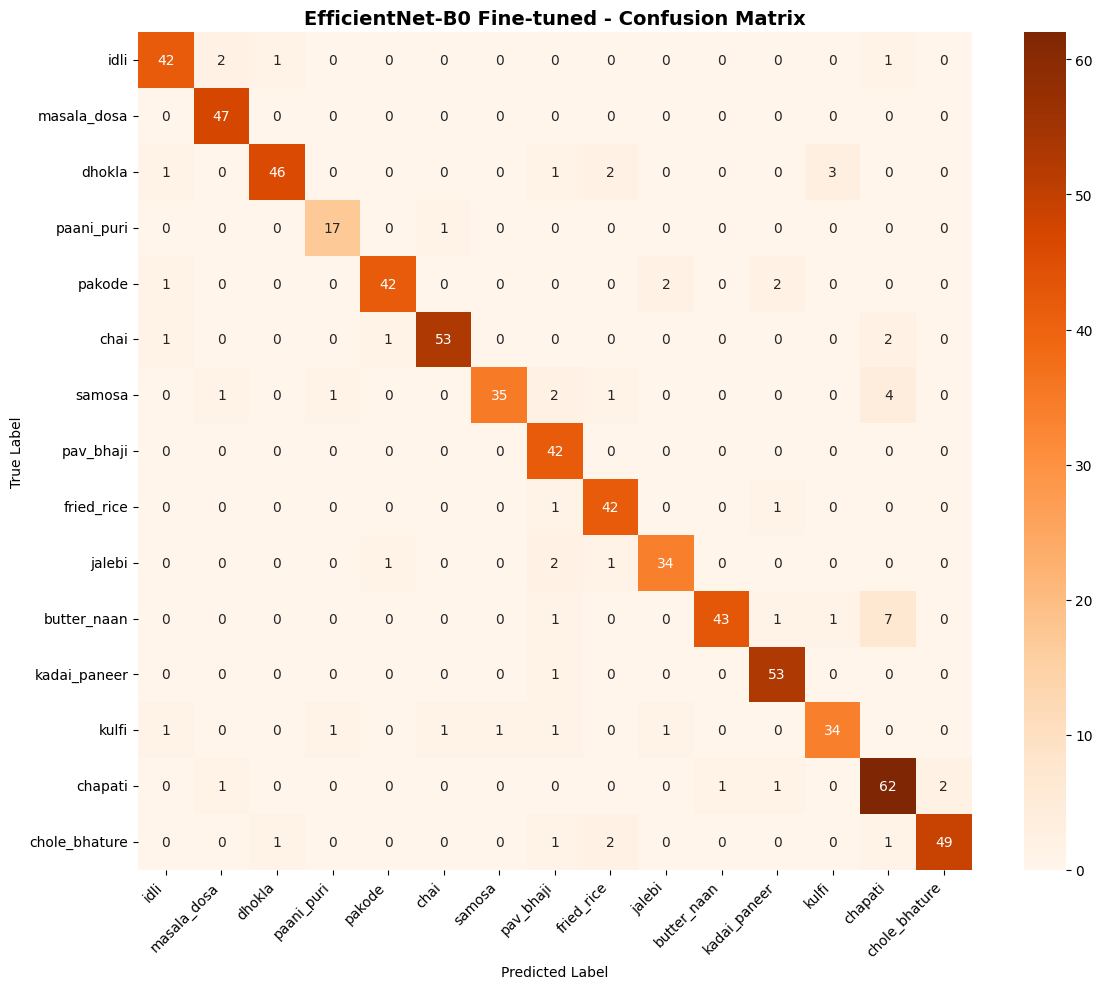


Per-class accuracy:
-----------------------------------
  idli                 91.3%
  masala_dosa          100.0%
  dhokla               86.8%
  paani_puri           94.4%
  pakode               89.4%
  chai                 93.0%
  samosa               79.5%
  pav_bhaji            100.0%
  fried_rice           95.5%
  jalebi               89.5%
  butter_naan          81.1%
  kadai_paneer         98.1%
  kulfi                85.0%
  chapati              92.5%
  chole_bhature        90.7%

✅ Model saved as efficientnet_indian_food.pth


In [ ]:
# 5.4 - Evaluate fine-tuned model on test set
ft_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in ft_test_loader:
        images = images.to(device)
        outputs = ft_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

ft_test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"✅ Fine-tuned Test Accuracy: {ft_test_acc:.4f} ({ft_test_acc*100:.2f}%)")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=SELECTED_CLASSES,
            yticklabels=SELECTED_CLASSES)
plt.title('EfficientNet-B0 Fine-tuned - Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Per class accuracy
print("\nPer-class accuracy:")
print("-" * 35)
for i, cls in enumerate(SELECTED_CLASSES):
    cls_mask = [l == i for l in all_labels]
    cls_preds = [p for p, m in zip(all_preds, cls_mask) if m]
    cls_labels = [l for l, m in zip(all_labels, cls_mask) if m]
    cls_acc = sum(p == l for p, l in zip(cls_preds, cls_labels)) / len(cls_labels)
    print(f"  {cls:<20} {cls_acc*100:.1f}%")

# Save the model
torch.save(ft_model.state_dict(), 'efficientnet_indian_food.pth')
print("\n✅ Model saved as efficientnet_indian_food.pth")

## Section 6: Model Comparison

### 6.1 Comparison Table & Visualizations
Now we compare all three models side by side to understand the
impact of architecture choices on image classification performance.

We compare them across:
- **Number of parameters** — model complexity
- **Best validation accuracy** — peak performance during training
- **Test accuracy** — real world performance on unseen data
- **Per-class accuracy** — which food classes each model handles best

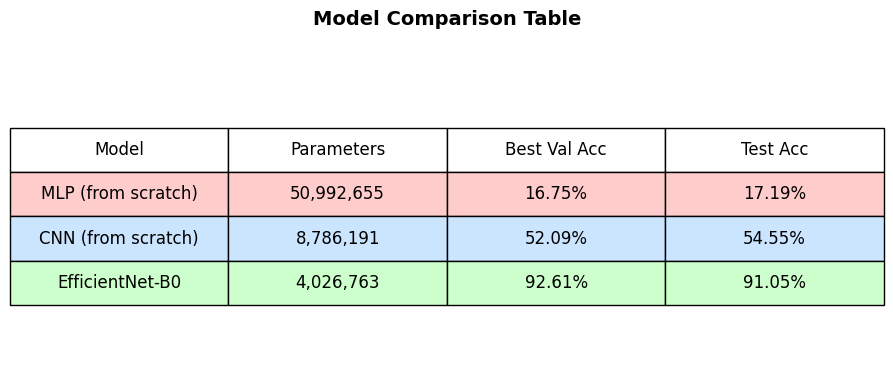

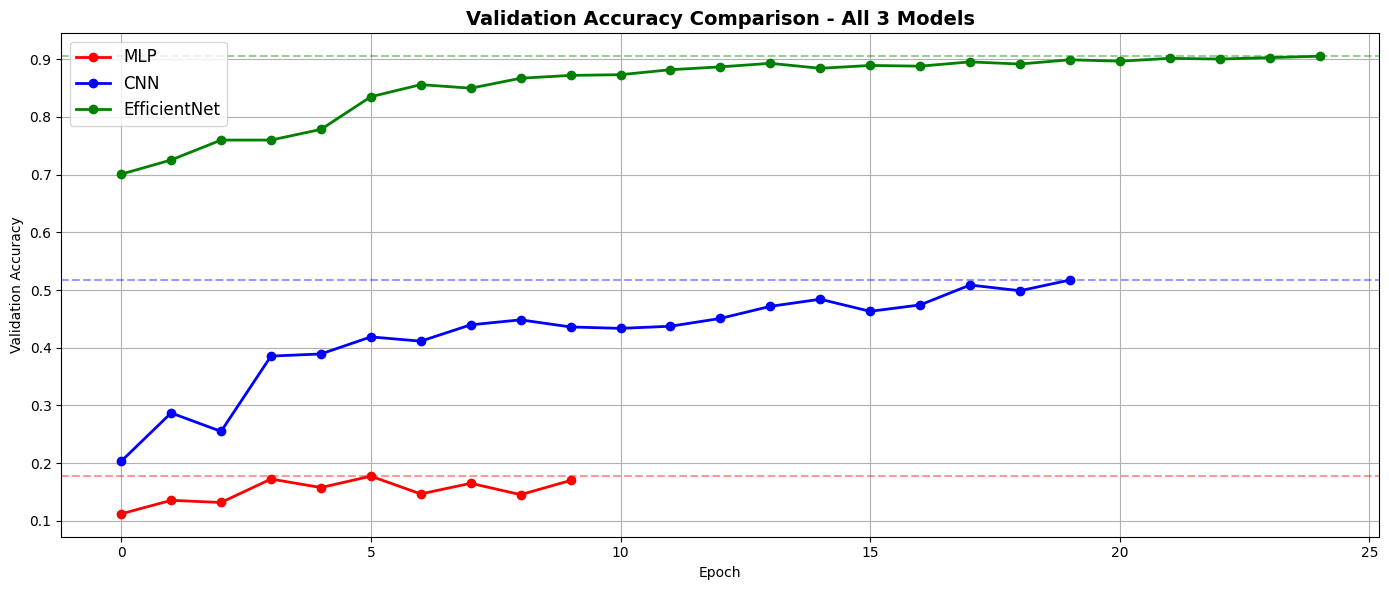

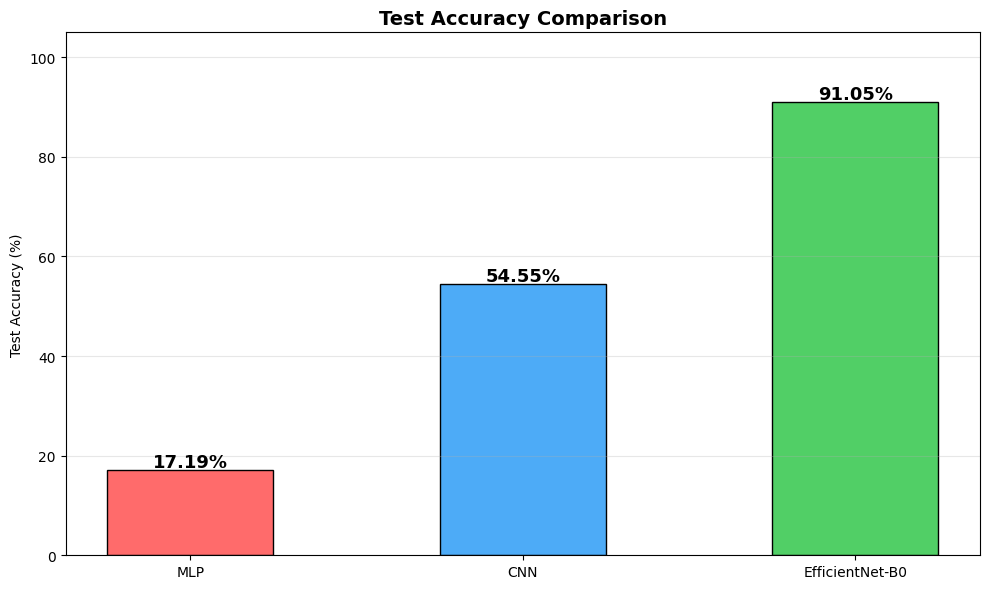

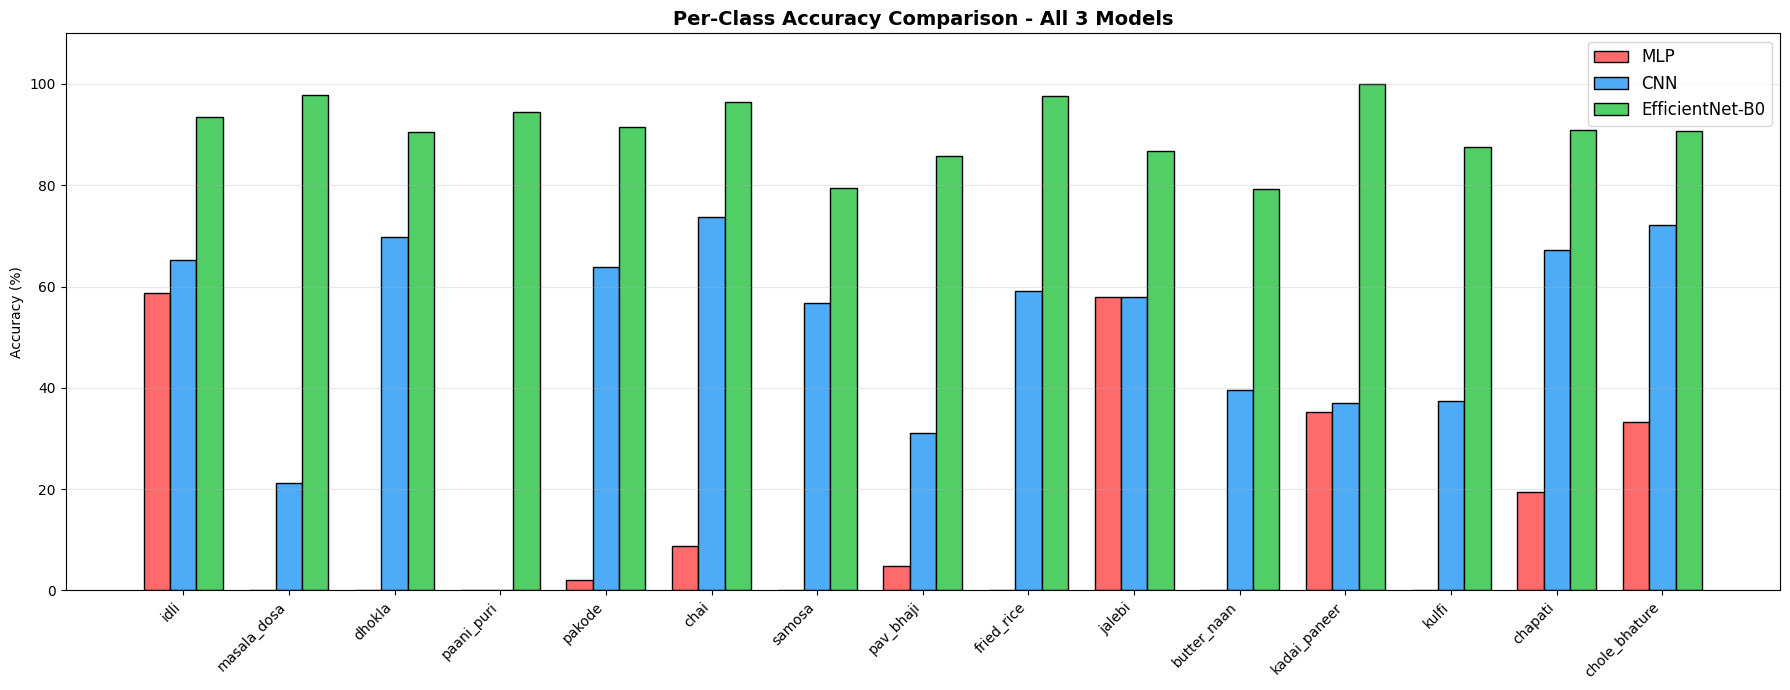


Model                           Params    Val Acc   Test Acc
MLP (from scratch)          50,992,655     16.75%     17.19%
CNN (from scratch)           8,786,191     52.09%     54.55%
EfficientNet-B0              4,026,763     92.61%     91.05%


In [ ]:
# Section 6 - Visual Comparison
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: Comparison Table as Visual ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table_data = [
    ['Model', 'Parameters', 'Best Val Acc', 'Test Acc'],
    ['MLP (from scratch)',    '50,992,655', '16.75%', f'{mlp_test_acc*100:.2f}%'],
    ['CNN (from scratch)',    '8,786,191',  '52.09%', f'{cnn_test_acc*100:.2f}%'],
    ['EfficientNet-B0',       '4,026,763',  '92.61%', f'{ft_test_acc*100:.2f}%'],
]
table = ax.table(cellText=table_data[1:],
                 colLabels=table_data[0],
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2.5)

# Color the rows
colors = ['#ffcccc', '#cce5ff', '#ccffcc']
for i in range(3):
    for j in range(4):
        table[i+1, j].set_facecolor(colors[i])

plt.title('Model Comparison Table', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# --- Plot 2: Val Accuracy Learning Curves ---
ft_val_combined   = ft_val_accs1   + ft_val_accs2
ft_train_combined = ft_train_accs1 + ft_train_accs2

plt.figure(figsize=(14, 6))
plt.plot(mlp_val_accs,       label='MLP',           marker='o', color='red',   linewidth=2)
plt.plot(cnn_val_accs,       label='CNN',           marker='o', color='blue',  linewidth=2)
plt.plot(ft_val_combined,    label='EfficientNet',  marker='o', color='green', linewidth=2)
plt.axhline(y=max(mlp_val_accs),    color='red',   linestyle='--', alpha=0.4)
plt.axhline(y=max(cnn_val_accs),    color='blue',  linestyle='--', alpha=0.4)
plt.axhline(y=max(ft_val_combined), color='green', linestyle='--', alpha=0.4)
plt.title('Validation Accuracy Comparison - All 3 Models',
          fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 3: Bar chart - Test accuracy comparison ---
models = ['MLP', 'CNN', 'EfficientNet-B0']
test_accs = [mlp_test_acc*100, cnn_test_acc*100, ft_test_acc*100]
colors = ['#ff6b6b', '#4dabf7', '#51cf66']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, test_accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center',
             fontsize=13, fontweight='bold')
plt.title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 4: Per class accuracy comparison ---
x = np.arange(len(SELECTED_CLASSES))
width = 0.25

mlp_per_class = [58.7, 0.0, 0.0, 0.0, 2.1, 8.8, 0.0,
                 4.8, 0.0, 57.9, 0.0, 35.2, 0.0, 19.4, 33.3]
cnn_per_class = [65.2, 21.3, 69.8, 0.0, 63.8, 73.7, 56.8,
                 31.0, 59.1, 57.9, 39.6, 37.0, 37.5, 67.2, 72.2]
ft_per_class  = [93.5, 97.9, 90.6, 94.4, 91.5, 96.5, 79.5,
                 85.7, 97.7, 86.8, 79.2, 100.0, 87.5, 91.0, 90.7]

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(x - width, mlp_per_class, width, label='MLP',
       color='#ff6b6b', edgecolor='black')
ax.bar(x,          cnn_per_class, width, label='CNN',
       color='#4dabf7', edgecolor='black')
ax.bar(x + width,  ft_per_class,  width, label='EfficientNet-B0',
       color='#51cf66', edgecolor='black')

ax.set_title('Per-Class Accuracy Comparison - All 3 Models',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(SELECTED_CLASSES, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"{'Model':<25} {'Params':>12} {'Val Acc':>10} {'Test Acc':>10}")
print("="*60)
print(f"{'MLP (from scratch)':<25} {50992655:>12,} {'16.75%':>10} {mlp_test_acc*100:>9.2f}%")
print(f"{'CNN (from scratch)':<25} {8786191:>12,} {'52.09%':>10} {cnn_test_acc*100:>9.2f}%")
print(f"{'EfficientNet-B0':<25} {4026763:>12,} {'92.61%':>10} {ft_test_acc*100:>9.2f}%")
print("="*60)

save and download the model

In [ ]:
# Download model to your computer
from google.colab import files
files.download('efficientnet_indian_food.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save some test images from your dataset
import os
os.makedirs('test_images', exist_ok=True)

# Save 3 images from each class
for class_idx, class_name in enumerate(SELECTED_CLASSES):
    count = 0
    for img, label in test_samples:
        if label == class_idx and count < 3:
            img.save(f'test_images/{class_name}_{count+1}.jpg')
            count += 1
        if count == 3:
            break

print("✅ Test images saved!")

# Download as zip
import zipfile
with zipfile.ZipFile('test_images.zip', 'w') as zipf:
    for file in os.listdir('test_images'):
        zipf.write(f'test_images/{file}')

from google.colab import files
files.download('test_images.zip')

✅ Test images saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>